<a href="https://colab.research.google.com/github/Meghana-kanne/NLP/blob/main/Lab11_2_LogisticRegression_Meghana_2403a52247_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

| Library              | Purpose                                   |
| -------------------- | ----------------------------------------- |
| pandas               | Used for loading and handling datasets    |
| numpy                | Used for numerical operations             |
| TfidfVectorizer      | Converts text into numerical features     |
| train_test_split     | Splits data into training and testing     |
| LogisticRegression   | Machine learning model for classification |
| metrics              | Used to evaluate model performance        |
| matplotlib / seaborn | Used to visualize confusion matrix        |


# **Load and Preprocess Data**

In [2]:
data = {
    'review': [
        "This movie is amazing",
        "I hated this film",
        "Wonderful acting and great story",
        "Terrible movie waste of time",
        "Best movie ever",
        "Worst movie ever"
    ],
    'sentiment': [1,0,1,0,1,0]
}

df = pd.DataFrame(data)

**Text Cleaning**

In [3]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

print(df[['review','clean_review']])

                             review                      clean_review
0             This movie is amazing             this movie is amazing
1                 I hated this film                 i hated this film
2  Wonderful acting and great story  wonderful acting and great story
3      Terrible movie waste of time      terrible movie waste of time
4                   Best movie ever                   best movie ever
5                  Worst movie ever                  worst movie ever


**Importance of Preprocessing**

Text preprocessing improves the quality of input data.
It removes unwanted characters, punctuation, and noise from text.

# **Feature Extraction (TF-IDF)**

In [4]:
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 13


**TF-IDF Explanation**

TF-IDF stands for Term Frequency – Inverse Document Frequency.
It converts text into numerical vectors.

# **Train Logistic Regression Model**

**Split Dataset**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train Model**

In [6]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

**Sigmoid Function Explanation**

Logistic Regression uses the sigmoid function to convert linear outputs into probabilities between 0 and 1.

If the probability is greater than 0.5, the model predicts positive class.

If it is less than 0.5, it predicts negative class.

# **Model Evaluation**

In [7]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



**Confusion Matrix**

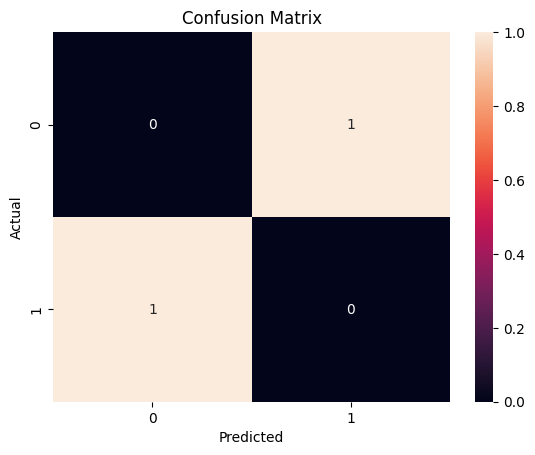

In [8]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Analysis**

Logistic Regression and Naive Bayes are popular algorithms used for text classification.

Naive Bayes assumes that all features are independent, which makes it simple and fast.
However, in real text data, words may be related to each other.

Logistic Regression learns weights for features without assuming independence.

It usually gives better accuracy when enough training data is available.

Naive Bayes is faster, but Logistic Regression often performs better for complex NLP tasks.